In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing import image_dataset_from_directory

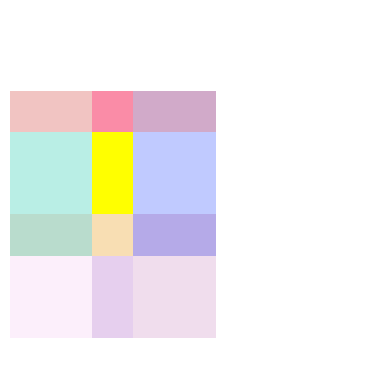

In [84]:
dir = "/content/Untitled.png"
img = keras.preprocessing.image.load_img(dir, target_size=(9, 9))

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

In [85]:
type(img)

PIL.PngImagePlugin.PngImageFile

In [86]:
img_array = keras.preprocessing.image.img_to_array(img)
# img_array = tf.expand_dims(img_array, 0)
img_array.shape

(9, 9, 3)

In [87]:
# Row, Colum, RGB
# img_array[0] -> Row
# img_array[0][0] -> column
# img_array[0][0][0] -> rgb

print(img_array)

[[[255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[241. 196. 194.]
  [241. 196. 194.]
  [250. 140. 167.]
  [209. 170. 201.]
  [209. 170. 201.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[185. 238. 229.]
  [185. 238. 229.]
  [255. 255.   0.]
  [192. 202. 255.]
  [192. 202. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[185. 238. 229.]
  [185. 238. 229.]
  [255. 255.   0.]
  [192. 202. 255.]
  [192. 202. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]
  [255. 255. 255.]]

 [[185. 220. 205.]
  [185. 220. 205.]
  [248. 222. 179.]
  [181. 170. 232.]
  [181. 170. 232.]
  [255. 255. 255.]
  [255. 255. 255.]
  

In [88]:
img_array[3]

array([[185., 238., 229.],
       [185., 238., 229.],
       [255., 255.,   0.],
       [192., 202., 255.],
       [192., 202., 255.],
       [255., 255., 255.],
       [255., 255., 255.],
       [255., 255., 255.],
       [255., 255., 255.]], dtype=float32)

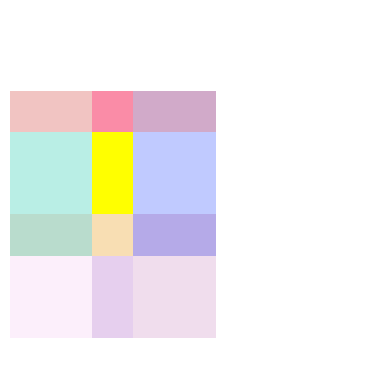

In [89]:

plt.imshow(img_array.astype("uint8"))
plt.axis("off")
plt.show()

In [90]:
x = img_array[3].copy()
# Second Value
x[1][0] = 250.0
x[1][1] = 22.0
x[1][2] = 125.0

#Third Value
x[2][0] = 55.0
x[2][1] = 225.0
x[2][2] = 125.0

In [91]:
x

array([[185., 238., 229.],
       [250.,  22., 125.],
       [ 55., 225., 125.],
       [192., 202., 255.],
       [192., 202., 255.],
       [255., 255., 255.],
       [255., 255., 255.],
       [255., 255., 255.],
       [255., 255., 255.]], dtype=float32)

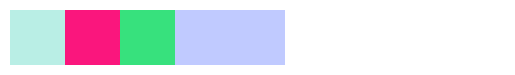

In [92]:
plt.imshow(x.reshape(1, 9, 3).astype("uint8"))
plt.axis("off")
plt.show()

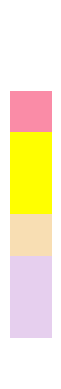

In [93]:
plt.imshow(img_array[:,2].reshape(9, 1, 3).astype("uint8"))
plt.axis("off")
plt.show()

In [94]:
type(img_array)

numpy.ndarray

In [95]:
img_array.shape

(9, 9, 3)

In [96]:
img_array = img_array/255.0

In [97]:
# img_array.min(), img_array.max(), img_array.std()
print(f'Min: {img_array.min()}')
print(f'Max: {img_array.max()}')
print(f'Std: {img_array.std()}')

Min: 0.0
Max: 1.0
Std: 0.12642107903957367


# Make Custom Convolutional Layer

In [133]:
import numpy as np

class CustomConv2D:
    def __init__(
        self,
        kernel=None,
        kernel_size=(3, 3),
        activation="relu",
        stride=1,
        padding="valid",
        bias=0.0
    ):
        self.kernel_size = kernel_size
        self.activation = activation
        self.stride = stride
        self.padding = padding
        self.bias = bias

        # Initialize kernel
        self.kernel = kernel if kernel is not None else self._default_kernel()

    # -----------------------------
    # Default "hardcore" kernel
    # -----------------------------
    def _default_kernel(self):
        return np.array([
            [-3, 0, 3],
            [-10, 0, 10],
            [-3, 0, 3]
        ], dtype=np.float32)

    # -----------------------------
    # Activation
    # -----------------------------
    def _activate(self, x):
        if self.activation == "relu":
            return np.maximum(0, x)
        elif self.activation == "tanh":
            return np.tanh(x)
        return x

    # -----------------------------
    # Padding helper
    # -----------------------------
    def _pad_image(self, image):
        if self.padding == "valid":
            return image

        pad_h = self.kernel.shape[0] // 2
        pad_w = self.kernel.shape[1] // 2

        if image.ndim == 2:
            return np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")

        if image.ndim == 3:
            return np.pad(
                image,
                ((pad_h, pad_h), (pad_w, pad_w), (0, 0)),
                mode="constant"
            )

        raise ValueError("Unsupported image shape")

    # -----------------------------
    # Core convolution (single channel)
    # -----------------------------
    def _convolve2d(self, image, kernel):
        image = image.astype(np.float32)
        image = self._pad_image(image)

        k_h, k_w = kernel.shape
        out_h = (image.shape[0] - k_h) // self.stride + 1
        out_w = (image.shape[1] - k_w) // self.stride + 1

        output = np.zeros((out_h, out_w), dtype=np.float32)

        for i in range(out_h):
            for j in range(out_w):
                region = image[
                    i * self.stride:i * self.stride + k_h,
                    j * self.stride:j * self.stride + k_w
                ]
                val = np.sum(region * kernel) + self.bias
                output[i, j] = self._activate(val)

        return output

    # -----------------------------
    # Grayscale
    # -----------------------------
    def convolve(self, image):
        return self._convolve2d(image, self.kernel)

    # -----------------------------
    # RGB (channel-wise conv)
    # -----------------------------
    def convolve_rgb(self, image):
        image = image.astype(np.float32)
        channels = []

        for c in range(3):
            ch = self._convolve2d(image[:, :, c], self.kernel)
            channels.append(ch)

        return np.stack(channels, axis=-1)

    # -----------------------------
    # Callable API
    # -----------------------------
    def __call__(self, image, mode="rgb"):
        if mode == "rgb":
            return self.convolve_rgb(image)
        elif mode == "gray":
            return self.convolve(image)
        else:
            raise ValueError("mode must be 'rgb' or 'gray'")

    # -----------------------------
    # Debug info
    # -----------------------------
    def __repr__(self):
        return (
            f"CustomConv2D(kernel={self.kernel.shape}, "
            f"stride={self.stride}, padding={self.padding}, "
            f"activation={self.activation})"
        )

In [134]:
conv = CustomConv2D()
convolved_image = conv(img_array)
# convolved_image = convolve_rgb(img_array, kernel)

In [135]:
convolved_image.shape

(7, 7, 3)

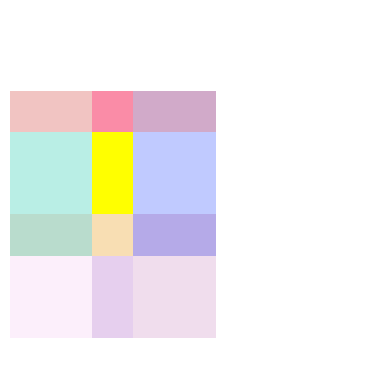

In [136]:
plt.imshow(img_array)
plt.axis("off")
plt.show()

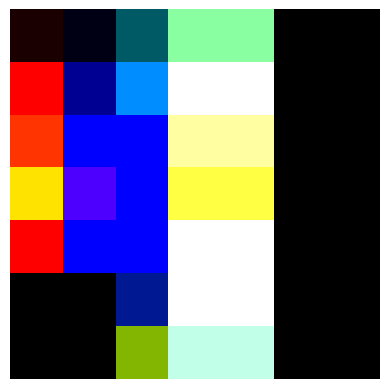

In [137]:
plt.imshow(convolved_image)
plt.axis("off")
plt.show()

shape: (5, 5, 3)


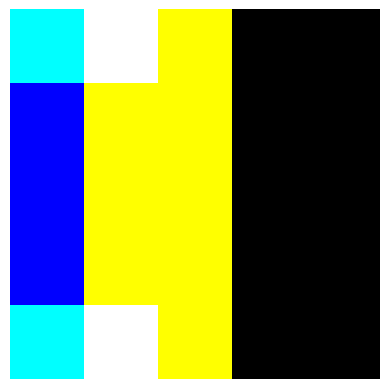

In [138]:
conv2 = CustomConv2D()
convolved_image2 = conv2(convolved_image)
print(f'shape: {convolved_image2.shape}')
plt.imshow(convolved_image2)
plt.axis("off")
plt.show()

shape: (3, 3, 3)


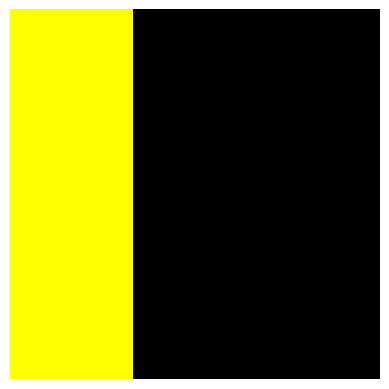

In [139]:
conv3 = CustomConv2D()
convolved_image3 = conv3(convolved_image2)
print(f'shape: {convolved_image3.shape}')
plt.imshow(convolved_image3)
plt.axis("off")
plt.show()